# Clinical demographics for discovery cohort

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(tidyverse)
  library(ComplexHeatmap)
})

In [ ]:
options(future.globals.maxSize = 1000000 * 1024^2, hpc.ncpus = 16)
plan(multicore, workers = getOption("hpc.ncpus", 1))

# Helper functions

In [2]:
source("../scripts/plotting.R")

# Load data

### Filtered dataset

QS object generated by running notebooks in `03_annotate`

In [ ]:
seu <- qs::qread(file = "../data/processed/cite_seq/cohort_treatment_naive/cellbender/annotated/annotated.qs", nthreads = getOption("hpc.ncpus", 1))

# Donor metadata

In [ ]:
donor.metadata <- read.table(
  file = "../data/metadata/donor_metadata.tsv",
  header = TRUE,
  sep = "\t",
  stringsAsFactors = FALSE
) %>%
  mutate(
    sex = factor(sex, levels = c("F", "M")),
    disease_type = factor(disease_type, levels = c("RR_high", "RR_low", "PP")),
    infusion_1_date = ymd(infusion_1_date)
  )

In [4]:
donor.metadata

donor_id,age,sex,bmi,disease_type,disease_duration,relapses_last_2_yr,relapses_last_yr,last_relapse_interval,mri_baseline_activity,relapses_on_ocrelizumab,mri_on_ocrelizumab_activity,edss_edmus,treatment_naive,prior_dmt,infusion_1_date,infusion_2_interval,infusion_3_interval,infusion_4_interval,infusion_5_interval
<chr>,<int>,<fct>,<dbl>,<fct>,<int>,<int>,<int>,<int>,<chr>,<int>,<chr>,<dbl>,<lgl>,<lgl>,<date>,<int>,<int>,<int>,<int>
OCRZ003,19,M,26.61,RR_high,0,4,4,4,new,0,none,1.0,TRUE,NA,2019-06-26,14,189,303,263
OCRZ004,24,F,22.48,RR_high,1,2,2,1,new,0,none,1.5,TRUE,NA,2019-07-10,14,226,259,252
OCRZ011,39,M,23.71,RR_low,0,1,1,4,enhancing,0,none,1.0,TRUE,NA,2019-09-11,14,405,483,427
OCRZ012,46,F,32.66,RR_high,1,6,2,9,none,0,none,6.0,TRUE,NA,2019-09-18,14,156,287,270
OCRZ013,44,F,26.78,RR_high,0,3,2,4,none,0,none,5.0,TRUE,NA,2019-10-02,14,307,343,322
OCRZ014,47,F,25.48,RR_high,1,4,3,8,enhancing,0,none,5.0,TRUE,NA,2019-11-06,14,328,290,270
OCRZ019,61,F,28.83,PP,2,0,0,NA,enhancing,0,none,6.0,TRUE,NA,2020-01-14,15,202,287,409
OCRZ020,24,F,23.83,RR_low,1,2,1,12,none,0,none,3.0,TRUE,NA,2020-01-07,14,308,385,280
OCRZ022,60,M,24.81,PP,3,0,0,NA,new,0,none,6.0,TRUE,NA,2020-01-29,14,202,231,245


### Cohort information summary

pdf 
  2

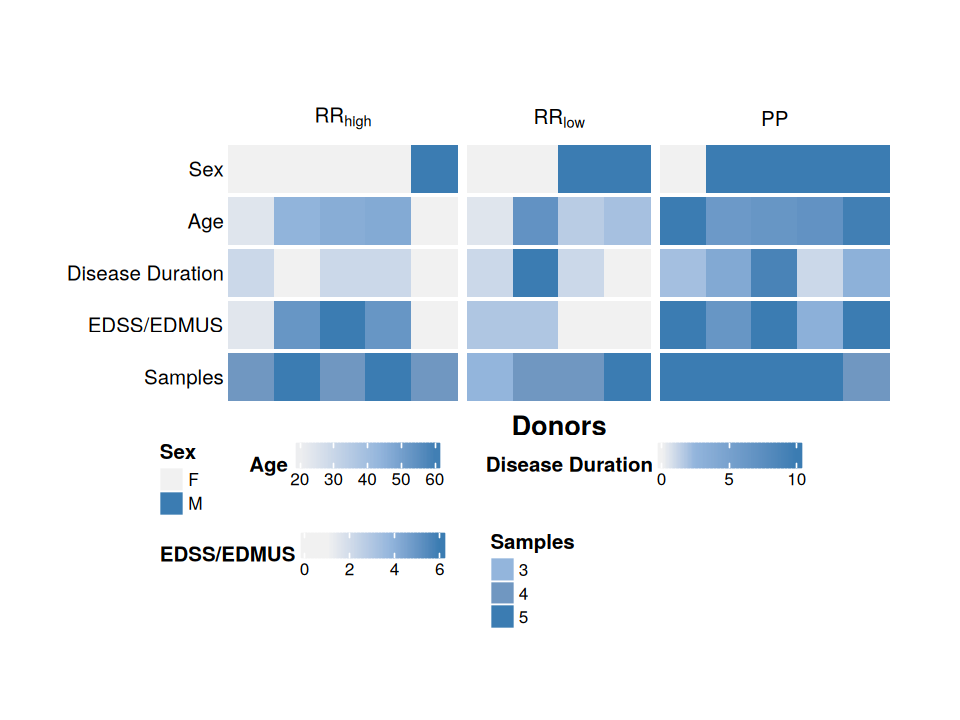

In [ ]:
options(repr.plot.width = 8, repr.plot.height = 6)

n_samples <- FetchData(seu, vars = c("donor", "hash_id")) %>%
  distinct() %>%
  group_by(donor) %>%
  summarise(n = n())

data <- donor.metadata %>%
  filter(donor_id != "3530194") %>% # exclude treatment-naive non-responder donor from heatmap (not in discovery cohort)
  arrange(disease_type, sex, age) %>%
  left_join(n_samples, by = c("donor_id" = "donor"))

h <- Heatmap(
  matrix = t(matrix(nrow = nrow(data), ncol = 0, dimnames = list(data$donor_id, NULL))),
  name = NULL,
  show_heatmap_legend = FALSE,
  cluster_columns = FALSE,
  show_column_names = FALSE,
  column_title = "Donors",
  column_title_side = "bottom",
  column_title_gp = gpar(fontsize = 16, fontface = "bold"),
  width = unit(nrow(data) * 1, "cm"),
  column_split = data$disease_type,
  column_gap = unit(2, "mm"),
  bottom_annotation = HeatmapAnnotation(
    `Disease Type` = anno_block(
      labels = c(expression("RR"["high"]), expression("RR"["low"]), expression("PP")),
      gp = gpar(col = NA)
    ),
    Sex = data$sex,
    Age = data$age,
    `Disease Duration` = data$disease_duration,
    `EDSS/EDMUS` = data$edss_edmus,
    Samples = as.character(data$n),
    col = list(
      Sex = pals::kovesi.linear_blue_95_50_c20(5)[c(1, 5)] %>% setNames(c("F", "M")),
      Age = circlize::colorRamp2(
        breaks = c(min(data$age), mean(data$age), max(data$age)),
        colors = c(pals::kovesi.linear_blue_95_50_c20(100)[1], pals::kovesi.linear_blue_95_50_c20(100)[50], pals::kovesi.linear_blue_95_50_c20(100)[100])
      ),
      `Disease Duration` = circlize::colorRamp2(
        breaks = c(min(data$disease_duration, na.rm = TRUE), mean(data$disease_duration, na.rm = TRUE), max(data$disease_duration, na.rm = TRUE)),
        colors = c(pals::kovesi.linear_blue_95_50_c20(100)[1], pals::kovesi.linear_blue_95_50_c20(100)[50], pals::kovesi.linear_blue_95_50_c20(100)[100])
      ),
      `EDSS/EDMUS` = circlize::colorRamp2(
        breaks = c(min(data$edss_edmus, na.rm = TRUE), mean(data$edss_edmus, na.rm = TRUE), max(data$edss_edmus, na.rm = TRUE)),
        colors = c(pals::kovesi.linear_blue_95_50_c20(100)[1], pals::kovesi.linear_blue_95_50_c20(100)[50], pals::kovesi.linear_blue_95_50_c20(100)[100])
      ),
      Samples = pals::kovesi.linear_blue_95_50_c20(5)[3:5] %>% setNames(as.character(3:5))
    ),
    gap = unit(0.1, "cm"),
    annotation_name_gp = gpar(fontsize = 12),
    annotation_name_side = "left",
    annotation_legend_param = list(
      Sex = list(
        title_position = "topleft",
        direction = "vertical",
        ncol = 1,
        grid_width = unit(0.5, "cm"),
        grid_height = unit(0.5, "cm"),
        title_gp = gpar(fontsize = 12, fontface = "bold"),
        labels_gp = gpar(fontsize = 10)
      ),
      Age = list(
        title_position = "leftcenter",
        direction = "horizontal",
        legend_width = unit(3, "cm"),
        grid_width = unit(0.5, "cm"),
        grid_height = unit(0.5, "cm"),
        title_gp = gpar(fontsize = 12, fontface = "bold"),
        labels_gp = gpar(fontsize = 10)
      ),
      `Disease Duration` = list(
        title_position = "leftcenter",
        direction = "horizontal",
        legend_width = unit(3, "cm"),
        grid_width = unit(0.5, "cm"),
        grid_height = unit(0.5, "cm"),
        title_gp = gpar(fontsize = 12, fontface = "bold"),
        labels_gp = gpar(fontsize = 10)
      ),
      `EDSS/EDMUS` = list(
        title_position = "leftcenter",
        direction = "horizontal",
        legend_width = unit(3, "cm"),
        grid_width = unit(0.5, "cm"),
        grid_height = unit(0.5, "cm"),
        title_gp = gpar(fontsize = 12, fontface = "bold"),
        labels_gp = gpar(fontsize = 10)
      ),
      Samples = list(
        title_position = "topleft",
        direction = "vertical",
        legend_height = unit(3, "cm"),
        grid_width = unit(0.5, "cm"),
        grid_height = unit(0.5, "cm"),
        title_gp = gpar(fontsize = 12, fontface = "bold"),
        labels_gp = gpar(fontsize = 10)
      )
    ),
    simple_anno_size = unit(1, "cm")
  )
)

draw(h,
  annotation_legend_side = "bottom",
  legend_gap = unit(1, "cm")
)

pdf(
  file = "../results/plots/cohort_treatment_naive_donor_metadata_heatmap.pdf",
  width = 8,
  height = 6
)
draw(h,
  annotation_legend_side = "bottom",
  legend_gap = unit(1, "cm")
)
dev.off()


In [8]:
n_samples <- FetchData(seu, vars = c("donor", "hash_id")) %>%
  distinct() %>%
  group_by(donor) %>%
  summarise(n = n())

data <- donor.metadata %>%
  select(
    donor_id,
    age,
    sex,
    bmi,
    disease_type,
    disease_duration,
    relapses_last_2_yr,
    relapses_last_yr,
    mri_baseline_activity,
    relapses_on_ocrelizumab,
    mri_on_ocrelizumab_activity,
    edss_edmus,
    infusion_2_interval,
    infusion_3_interval,
    infusion_4_interval,
    infusion_5_interval
  ) %>% 
  rename(
    `Donor ID` = donor_id,
    Age = age,
    Sex = sex,
    BMI = bmi,
    `Disease Type` = disease_type,
    `Disease Duration (Years)` = disease_duration,
    `24 months` = relapses_last_2_yr,
    `12 months` = relapses_last_yr,
    `Baseline MRI Activity` = mri_baseline_activity,
    `Post-treatment Relapses` = relapses_on_ocrelizumab,
    `Follow up MRI Activity` = mri_on_ocrelizumab_activity,
    `EDSS/EDMUS` = edss_edmus
  ) %>%
  rename_with(
    function(x) str_extract(string = x, pattern = "^infusion_(\\d+)_interval$", group = 1),
    starts_with("infusion_")
  )

for (donor in n_samples$donor) {
  for (x in as.character(2:5)) {
    if (x > as.integer(n_samples$n[n_samples$donor == donor])) {
      data[data$`Donor ID` == donor, x] <- NA
    }
  }
}

data

Donor ID,Age,Sex,BMI,Disease Type,Disease Duration (Years),24 months,12 months,Baseline MRI Activity,Post-treatment Relapses,Follow up MRI Activity,EDSS/EDMUS,2,3,4,5
<chr>,<dbl>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
OCRZ003,19,M,26.61,RR_high,0,4,4,new,0,none,1.0,14,189,303,NA
OCRZ004,24,F,22.48,RR_high,1,2,2,new,0,none,1.5,14,226,259,NA
OCRZ011,39,M,23.71,RR_low,0,1,1,enhancing,0,none,1.0,14,405,483,427
OCRZ012,46,F,32.66,RR_high,1,6,2,none,0,none,6.0,14,156,287,NA
OCRZ013,44,F,26.78,RR_high,0,3,2,none,0,none,5.0,14,307,343,322
OCRZ014,47,F,25.48,RR_high,1,4,3,enhancing,0,none,5.0,14,328,290,270
OCRZ019,61,F,28.83,PP,2,0,0,enhancing,0,none,6.0,15,202,287,409
OCRZ020,24,F,23.83,RR_low,1,2,1,none,0,none,3.0,14,308,NA,NA
OCRZ022,60,M,24.81,PP,3,0,0,new,0,none,6.0,14,202,231,NA


In [ ]:
openxlsx::write.xlsx(
  x = data,
  file = "../results/tables/cite_seq/cohort_treatment_naive/clinical_demographics.xlsx",
  sheetName = "Clinical Demographics",
  overwrite = TRUE
)

### Infusion interval

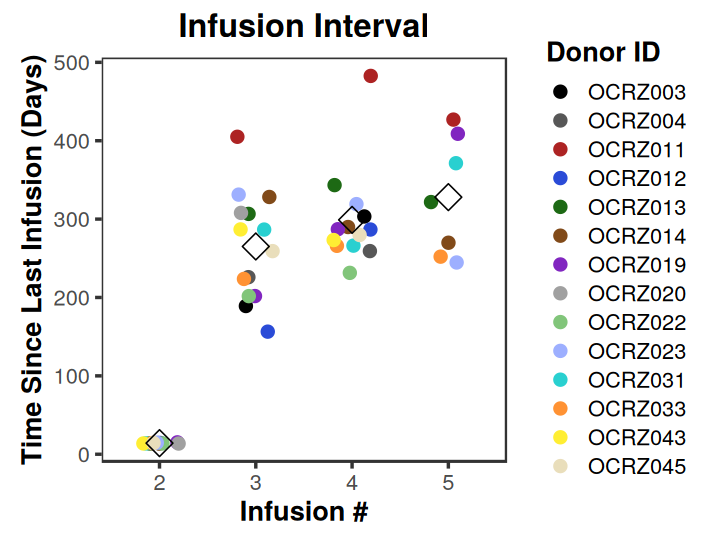

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 4.5)

set.seed(42)

ggplot(
  data = donor.metadata %>%
    pivot_longer(
      cols = ends_with("_interval"),
      names_to = "infusion",
      values_to = "interval"
    ) %>%
    mutate(
      donor = donor_id,
      infusion = factor(str_extract(string = infusion, pattern = "infusion_(\\d+)", group = 1)),
    ) %>%
    select(
      donor,
      infusion,
      interval
    ) %>%
    right_join(distinct(seu[[c("donor", "hash_id")]]), by = c("donor" = "donor", "infusion" = "hash_id")) %>%
    drop_na(),
  mapping = aes(x = infusion, y = interval)
) +
  geom_jitter(mapping = aes(colour = donor), width = 0.2, size = 3) +
  stat_summary(fun = mean, geom = "point", size = 5, shape = 5) +
  scale_colour_manual(values = pals::watlington(14)) +
  labs(title = "Infusion Interval", x = "Infusion #", y = "Time Since Last Infusion (Days)", colour = "Donor ID") +
  theme_custom() +
  theme(
    aspect.ratio = 1,
    plot.title = element_text(face = "bold", hjust = 0.5),
    axis.title = element_text(face = "bold"),
    legend.title = element_text(face = "bold")
  )

ggsave(
  filename = "../results/plots/cohort_treatment_naive_infusion_interval.pdf",
  width = 6,
  height = 4.5
)

# Session Info

In [25]:
sessionInfo()

R version 4.3.3 (2024-02-29)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /ceph/project/fuggerlab/rfarooq/.conda/envs/sandbox/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
[1] C

time zone: Europe/London
tzcode source: system (glibc)

attached base packages:
[1] grid      stats     graphics  grDevices utils     datasets  methods  
[8] base     

other attached packages:
 [1] ComplexHeatmap_2.18.0 lubridate_1.9.3       forcats_1.0.0        
 [4] stringr_1.5.1         dplyr_1.1.4           purrr_1.0.2          
 [7] readr_2.1.5           tidyr_1.3.1           tibble_3.2.1         
[10] ggplot2_3.5.1         tidyverse_2.0.0       Seurat_5.1.0         
[13] SeuratObject_5.0.2    sp_2.1-4             

loaded via a namespace (and not attached):
  [1] RColorBrewer_1.1-3     shape_1.4.6.1          jsonlite_1.8.9        
  [4] magrittr_2.0.3         spatstat.utils_3.1-0   farver_2.1.2          
  [7] ragg_1.3.